In [3]:
import torch
from Model import SiameseNetwork
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

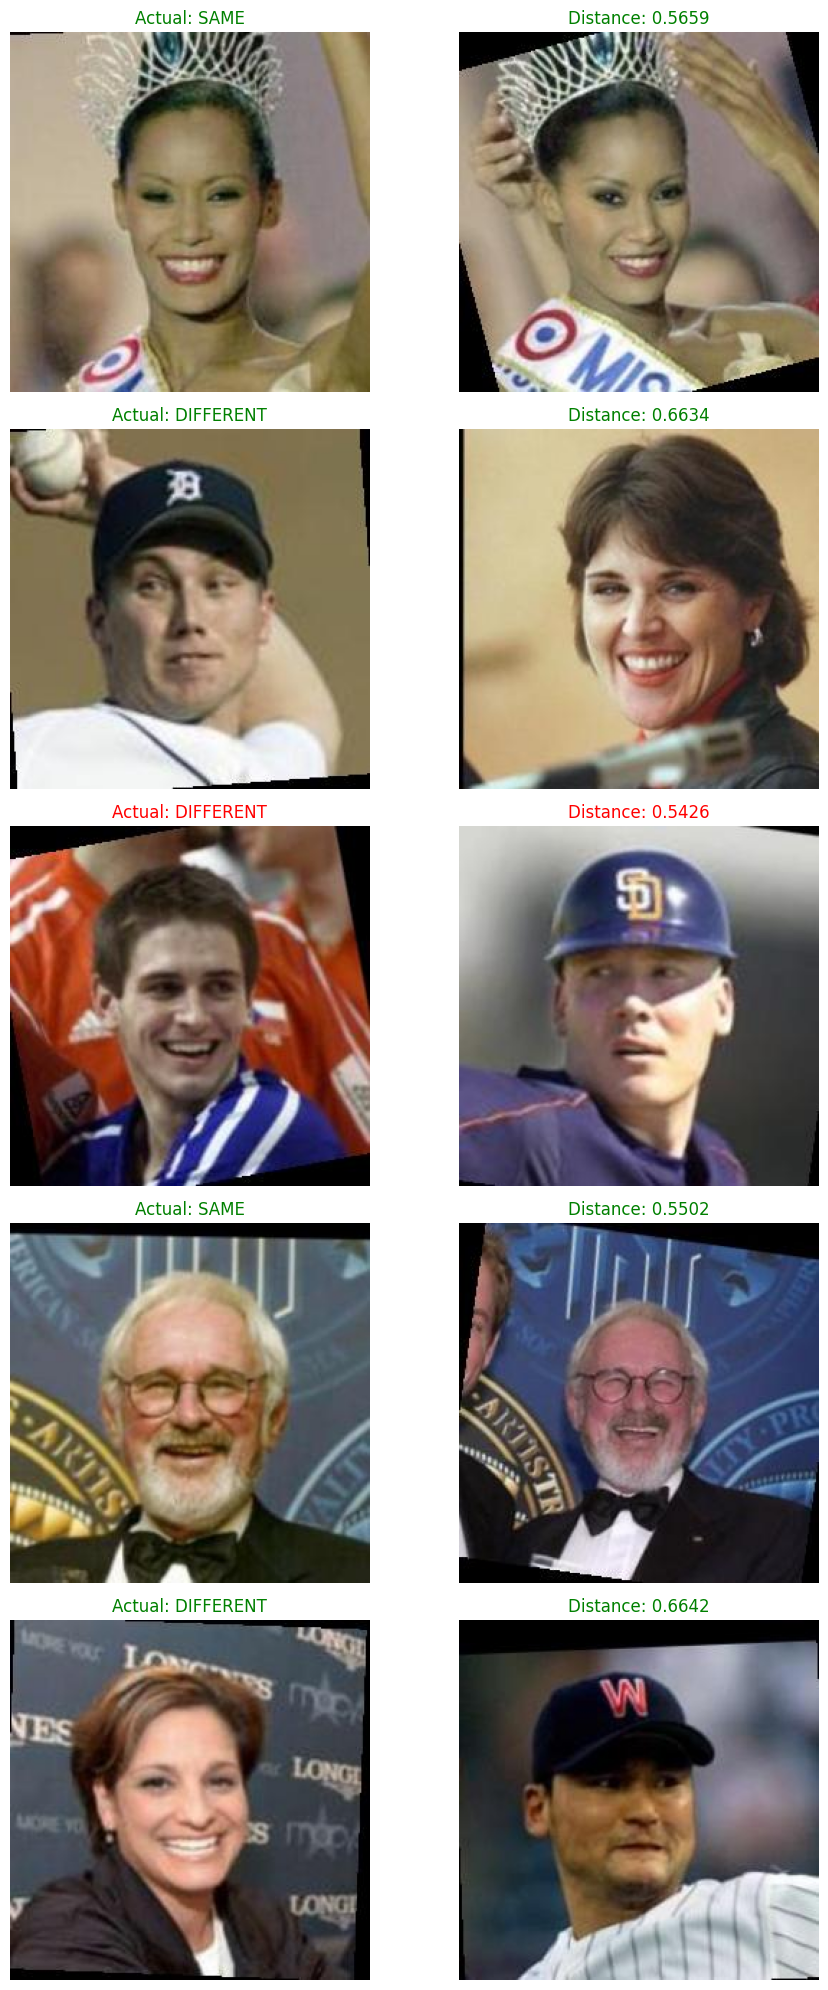

In [5]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork().to(device)
model.load_state_dict(torch.load('siamese_resnet18.pth'))
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def plot_test_pairs(model, data_path, num_pairs=5):
    all_people = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    fig, axes = plt.subplots(num_pairs, 2, figsize=(10, 4 * num_pairs))
    
    threshold = 0.6

    with torch.no_grad():
        for i in range(num_pairs):
            is_same = random.random() > 0.5
            if is_same:
                person = random.choice([p for p in all_people if len(os.listdir(os.path.join(data_path, p))) >= 2])
                p_path = os.path.join(data_path, person)
                img_paths = random.sample([os.path.join(p_path, f) for f in os.listdir(p_path)], 2)
                label_text = "SAME"
            else:
                p1, p2 = random.sample(all_people, 2)
                img_paths = [
                    os.path.join(data_path, p1, random.choice(os.listdir(os.path.join(data_path, p1)))),
                    os.path.join(data_path, p2, random.choice(os.listdir(os.path.join(data_path, p2))))
                ]
                label_text = "DIFFERENT"

            img1_raw = Image.open(img_paths[0]).convert("RGB")
            img2_raw = Image.open(img_paths[1]).convert("RGB")
            
            img1 = test_transform(img1_raw).unsqueeze(0).to(device)
            img2 = test_transform(img2_raw).unsqueeze(0).to(device)
            
            feat1, feat2 = model(img1, img2)
            dist = torch.nn.functional.pairwise_distance(feat1, feat2).item()
            
            is_correct = (is_same and dist < threshold) or (not is_same and dist >= threshold)
            title_color = 'green' if is_correct else 'red'
            
            axes[i, 0].imshow(img1_raw)
            axes[i, 1].imshow(img2_raw)
            
            axes[i, 0].set_title(f"Actual: {label_text}", color=title_color)
            axes[i, 1].set_title(f"Distance: {dist:.4f}", color=title_color)
            axes[i, 0].axis('off'); axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

PATH = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4/lfw-deepfunneled/lfw-deepfunneled/"
plot_test_pairs(model, PATH)